In [180]:
from hossam import load_data
from pandas import DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
from math import sqrt
# 가정 확인을 위한 라이브러리
from scipy.stats import t, normaltest, bartlett, levene
# 분산분석을 위한 라이브러리
from pingouin import anova
from pingouin import welch_anova
# 사후검정을 위한 라이브러리
from pingouin import pairwise_tukey, pairwise_tests,pairwise_gameshowell

In [181]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐

📘 문제 1<br>
tree_weight 데이터셋은 소나무 품종별 무게를 조사한 데이터이다. 소나무 품종별로 평균 무게<br>
에 차이가 있는지 분석하라.<br>

In [182]:
origin = load_data('tree_weight')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/tree_weight.xlsx
[desc] 소나무 품종별 무게를 조사한 데이터 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (30, 2)
열 개수: 2
행 개수: 30

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   weight  30 non-null     float64
 1   group   30 non-null     object 
dtypes: float64(1), object(1)
memory usage: 612.0+ bytes
None


,weight,group
0,4.17,A
1,5.58,A
2,5.18,A
3,6.11,A
4,4.50,A


In [183]:
df_wide = origin.pivot(columns='group', values='weight')
print(df_wide)



group     A     B     C
0      4.17   NaN   NaN
1      5.58   NaN   NaN
2      5.18   NaN   NaN
3      6.11   NaN   NaN
4      4.50   NaN   NaN
5      4.61   NaN   NaN
6      5.17   NaN   NaN
7      4.53   NaN   NaN
8      5.33   NaN   NaN
9      5.14   NaN   NaN
10      NaN  4.81   NaN
11      NaN  4.17   NaN
12      NaN  4.41   NaN
13      NaN  3.59   NaN
14      NaN  5.87   NaN
15      NaN  3.83   NaN
16      NaN  6.03   NaN
17      NaN  4.89   NaN
18      NaN  4.32   NaN
19      NaN  4.69   NaN
20      NaN   NaN  6.31
21      NaN   NaN  5.12
22      NaN   NaN  5.54
23      NaN   NaN  5.50
24      NaN   NaN  5.37
25      NaN   NaN  5.29
26      NaN   NaN  4.92
27      NaN   NaN  6.15
28      NaN   NaN  5.80
29      NaN   NaN  5.26


log-format 실험데이터

In [184]:
df_wide.fillna(0)

group,A,B,C
0,4.17,0.00,0.00
1,5.58,0.00,0.00
2,5.18,0.00,0.00
3,6.11,0.00,0.00
4,4.50,0.00,0.00
5,4.61,0.00,0.00
6,5.17,0.00,0.00
7,4.53,0.00,0.00
8,5.33,0.00,0.00
9,5.14,0.00,0.00


NAN이 있는 열(column) 삭제

In [185]:
column_drop = df_wide.dropna(axis=1)
column_drop

group
0
1
2
3
4
5
6
7
8
9


결측치 확인

In [186]:
df_wide.isna().sum()


group
A    20
B    20
C    20
dtype: int64

In [187]:
df = df_wide.dropna()
df

group,A,B,C


📘 #02. 데이터 분포 및 가정 확인

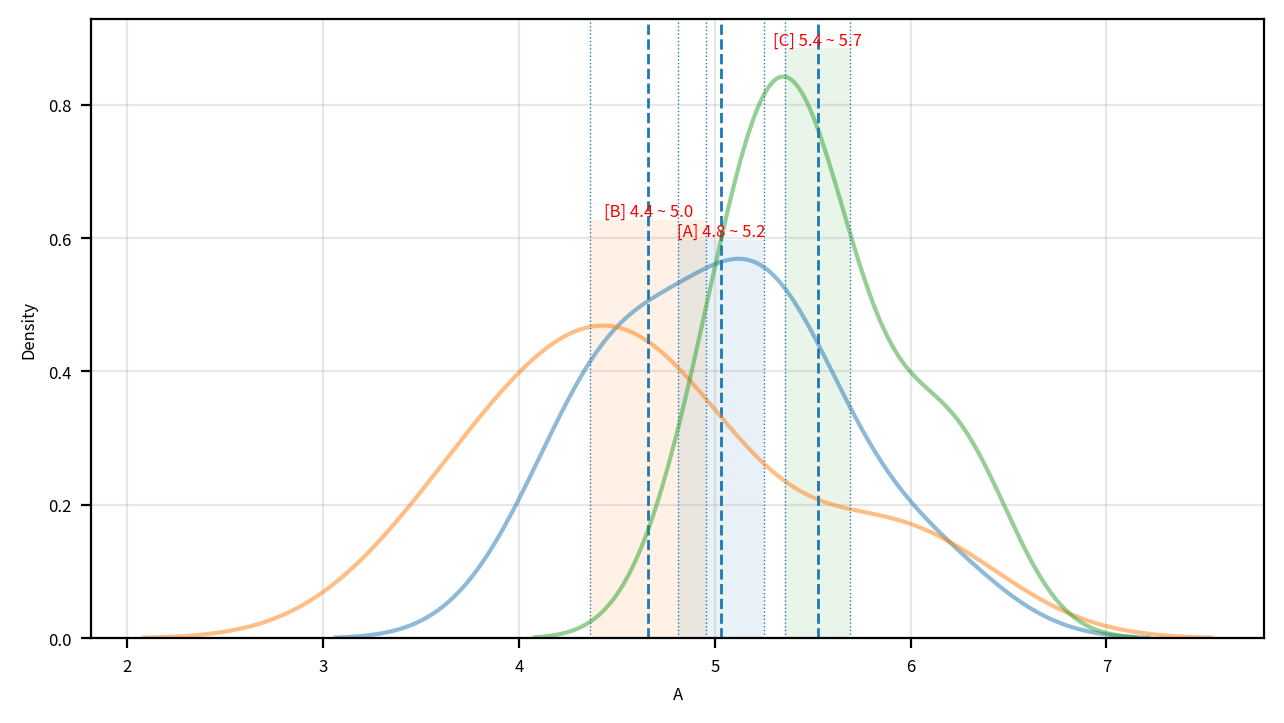

In [213]:
# 📝 [1] 데이터 분포
data =df_wide[['A','B','C']] # 확인할 데이터
# ---------------------------------
# 데이터 분포 / 신뢰구간 시각화
# ---------------------------------
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)
    # 신뢰구간
    max = data[c].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(data[c]) - 1 # 자유도
    sp_mean = data[c].mean() # 표본평균
    sp_std = data[c].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)
    # 평균 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax.text(x=(cmax-cmin)/2+cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"})
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시/숨김
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📝 2. 데이터 분포 확인-T

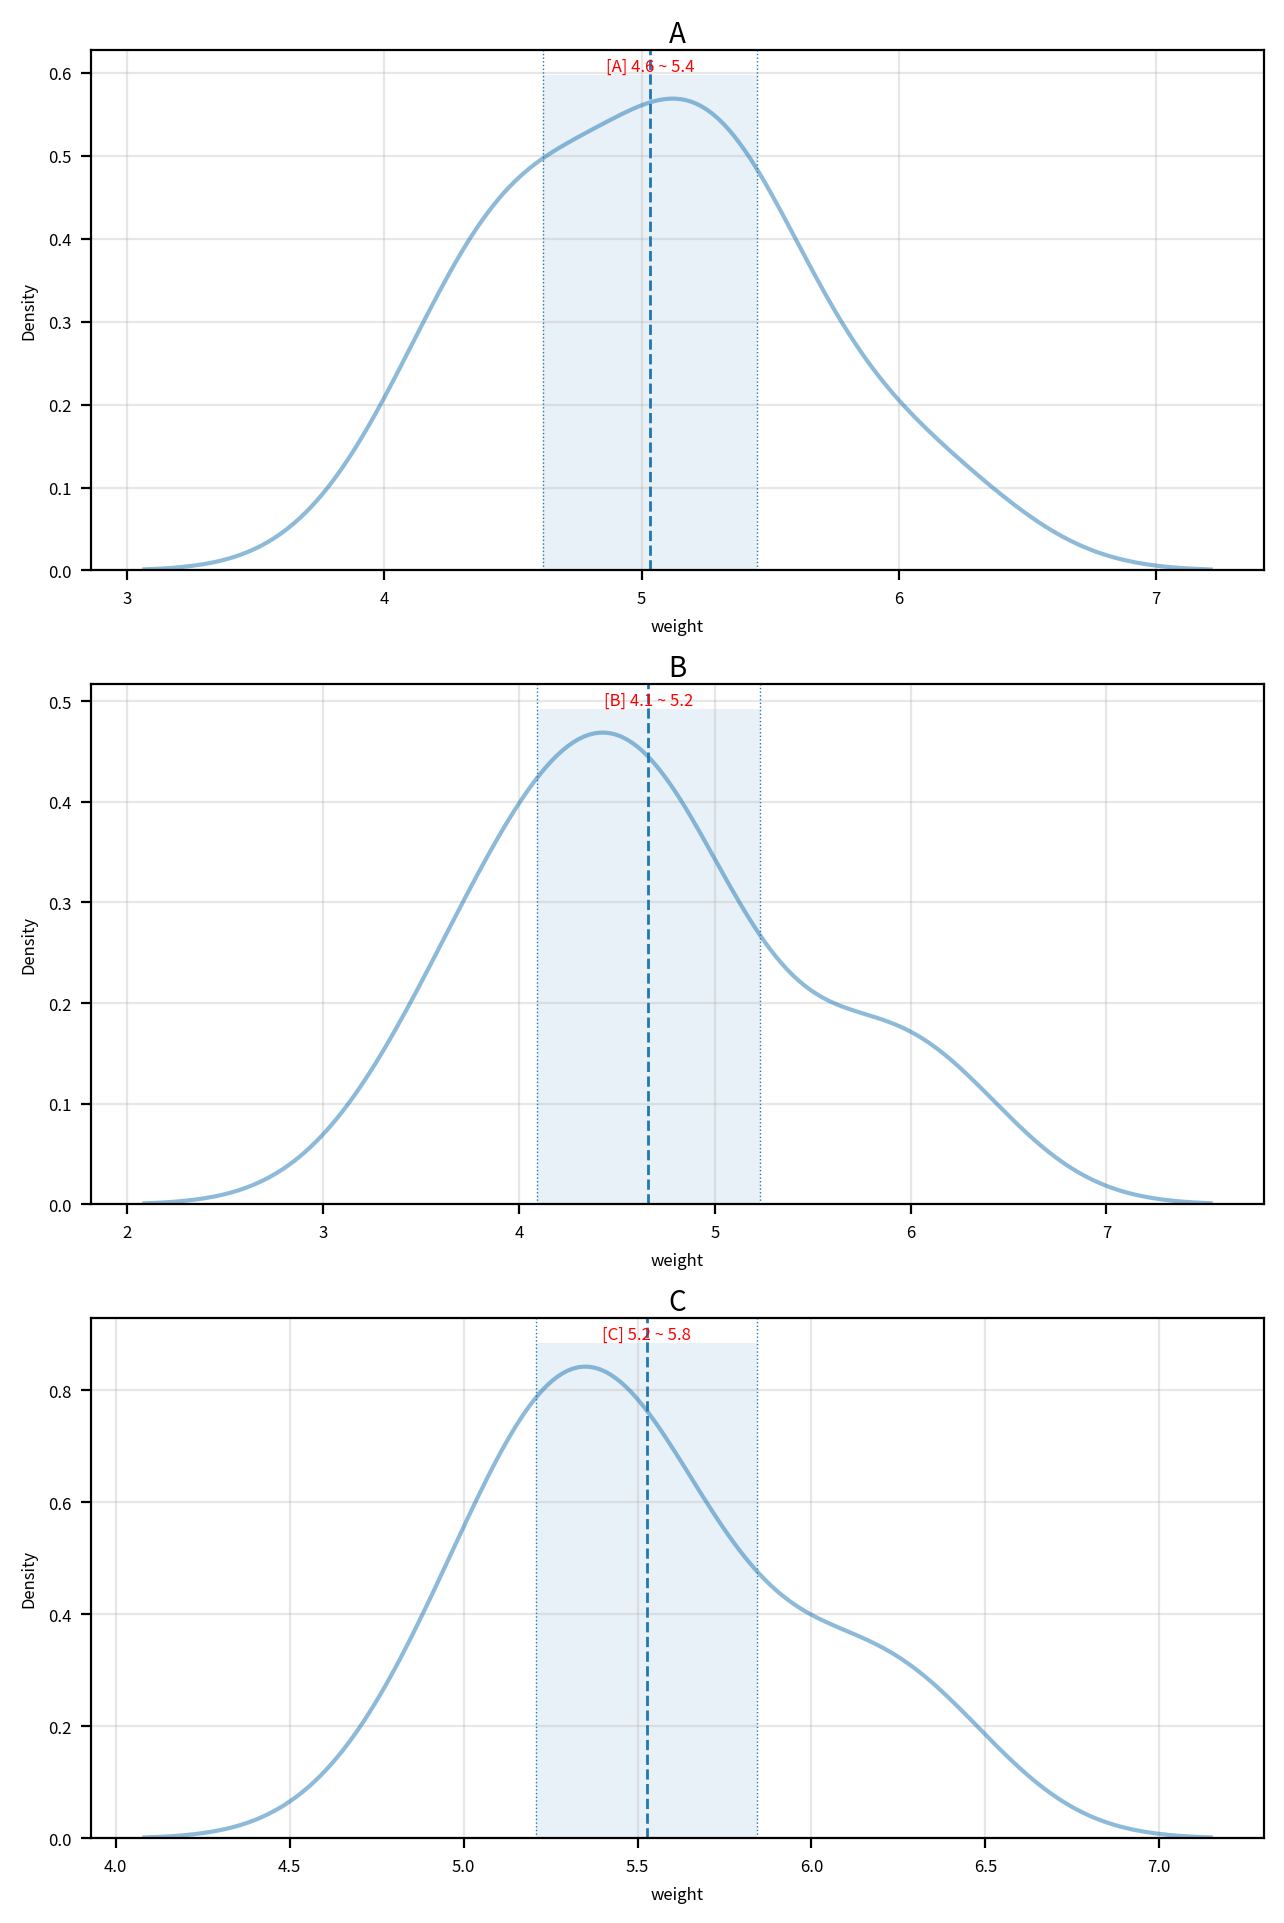

In [216]:
field = 'weight' # 확인할 데이터 필드
hue_field = 'group' # 집단을 구분하는 필드 (hue)
df = origin[[field, hue_field]] # 필요한 데이터 추출
hue_values = df[hue_field].unique() # 집단별 종류 구하기
hue_count = len(hue_values) # 집단의 종류 수
# 1) 그래프 초기화
rows = len(hue_values) # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for i, v in enumerate(hue_values):
    temp = df[df[hue_field] == v]
    # KDE Plot 그리기
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)
    # 신뢰구간
    max = temp[field].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(temp[field]) - 1 # 자유도
    sp_mean = temp[field].mean() # 표본평균
    sp_std = temp[field].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp[field])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
# 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (v, cmin, cmax),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료


pingouin 사용시

In [191]:
import pingouin as pg

anova_result = pg.anova(data=origin, dv='weight', between='group')
print(anova_result)

# p-value만 출력
p_value = anova_result['p-unc'][0]
np2 = anova_result['np2'][0]
print("p-value:", p_value)
print(f"p-value의 값이{p_value}인 것으로 보아, 세 개의 그룹간의 차이가 유의미한 것으로나타났습니다.")
print(f"즉 적어도 하나 이상의 그룹은 평균이 다릅니다")
print(f"또한, np2 = {np2}이므로, 품종 간의 무게 차이는 꽤 큰 것으로 볼 수 있습니다.")

  Source  ddof1  ddof2         F    p-unc       np2
0  group      2     27  4.846088  0.01591  0.264148
p-value: 0.015909958325622895
p-value의 값이0.015909958325622895인 것으로 보아, 세 개의 그룹간의 차이가 유의미한 것으로나타났습니다.
즉 적어도 하나 이상의 그룹은 평균이 다릅니다
또한, np2 = 0.26414829683211977이므로, 품종 간의 무게 차이는 꽤 큰 것으로 볼 수 있습니다.


사후검정

In [217]:
import pingouin as pg
import pandas as pd
from scipy.stats import levene, shapiro

# =====================================================
# 1. 그룹 분리
# =====================================================
groups = origin['group'].unique()

group_data = {g: origin[origin['group'] == g]['weight'] for g in groups}

# =====================================================
# 2. 정규성 검정 (Shapiro-Wilk)
# =====================================================
print("=== 정규성 검정 (Shapiro-Wilk) ===")
normality_results = {}
for g in groups:
    stat, p = shapiro(group_data[g])
    normality_results[g] = p
    print(f"{g} 그룹: p-value={p:.4f} → {'정규성 만족' if p>0.05 else '정규성 위배'}")

print()

# =====================================================
# 3. 등분산성 검정 (Levene test)
# =====================================================
print("=== 등분산성 검정 (Levene) ===")
stat, p_levene = levene(*group_data.values())
print(f"Levene p-value={p_levene:.4f} → {'등분산 만족' if p_levene>0.05 else '등분산 위배'}")
print()

# =====================================================
# 4. ANOVA 실행 (조건에 따라 자동 선택)
# =====================================================
print("=== ANOVA 결과 ===")
if p_levene > 0.05:
    print("등분산 만족 → 일반 ANOVA 적용")
    anova_result = pg.anova(data=origin, dv='weight', between='group')
else:
    print("등분산 위배 → Welch ANOVA 적용")
    anova_result = pg.welch_anova(data=origin, dv='weight', between='group')

print(anova_result)
p_anova = anova_result['p-unc'][0]
print(f"\nANOVA p-value = {p_anova:.6f}")

if p_anova <= 0.05:
    print("결론: 그룹 간 평균 차이가 **유의미함**\n")
else:
    print("결론: 그룹 간 평균 차이가 **유의미하지 않음**\n")

# =====================================================
# 5. 사후검정 Post-hoc test
# =====================================================
print("=== 사후검정 (Post-hoc test) ===")
if p_levene > 0.05:
    print("등분산 만족 → Tukey HSD 사용\n")
    posthoc = pg.pairwise_tukey(data=origin, dv='weight', between='group')
else:
    print("등분산 위배 → Games-Howell 사용\n")
    posthoc = pg.pairwise_gameshowell(data=origin, dv='weight', between='group')

print(posthoc)

# =====================================================
# 6. 사후검정 해석 자동 생성
# =====================================================
print("\n=== 사후검정 자동 해석 ===")

for i in range(len(posthoc)):
    row = posthoc.iloc[i]
    g1, g2 = row['A'], row['B']
    pval = row['p-tukey']
    mean_diff = row['diff']

    if pval <= 0.05:
        print(f"{g1} 그룹과 {g2} 그룹은 **유의미한 차이 있음** (p={pval:.4f}, 평균차={mean_diff:.3f})")
    else:
        print(f"{g1} 그룹과 {g2} 그룹은 유의미한 차이 없음 (p={pval:.4f})")
    





=== 정규성 검정 (Shapiro-Wilk) ===
A 그룹: p-value=0.7475 → 정규성 만족
B 그룹: p-value=0.4519 → 정규성 만족
C 그룹: p-value=0.5643 → 정규성 만족

=== 등분산성 검정 (Levene) ===
Levene p-value=0.3412 → 등분산 만족

=== ANOVA 결과 ===
등분산 만족 → 일반 ANOVA 적용
  Source  ddof1  ddof2         F    p-unc       np2
0  group      2     27  4.846088  0.01591  0.264148

ANOVA p-value = 0.015910
결론: 그룹 간 평균 차이가 **유의미함**

=== 사후검정 (Post-hoc test) ===
등분산 만족 → Tukey HSD 사용

   A  B  mean(A)  mean(B)   diff        se         T   p-tukey    hedges
0  A  B    5.032    4.661  0.371  0.278782  1.330791  0.390871  0.510237
1  A  C    5.032    5.526 -0.494  0.278782 -1.771996  0.197996 -0.914038
2  B  C    4.661    5.526 -0.865  0.278782 -3.102787  0.012006 -1.289277

=== 사후검정 자동 해석 ===
A 그룹과 B 그룹은 유의미한 차이 없음 (p=0.3909)
A 그룹과 C 그룹은 유의미한 차이 없음 (p=0.1980)
B 그룹과 C 그룹은 **유의미한 차이 있음** (p=0.0120, 평균차=-0.865)


📝 3. 정규성, 등분산성 검정-T

(1) 집단별 데이터 재구성 –> 피벗테이블

In [226]:
import pandas as pd
from pandas import pivot_table
field = 'weight' # 확인할 데이터 필드
hue_field = 'group' # 집단을 구분하는 필드 (hue)
df = origin.filter([field, hue_field]) # 필요한 데이터 추출
df['idx'] = df.groupby(hue_field).cumcount()
data = pivot_table(df, index='idx', columns=hue_field, values=field)
data

group,A,B,C
idx,,,
0,4.17,4.81,6.31
1,5.58,4.17,5.12
2,5.18,4.41,5.54
3,6.11,3.59,5.50
4,4.50,5.87,5.37
5,4.61,3.83,5.29
6,5.17,6.03,4.92
7,4.53,4.89,6.15
8,5.33,4.32,5.80


(2) 피벗 테이블을 활용하여 정규성, 등분산성 검정

In [237]:
equal_var_fields = []
normal_dist = True
report = []
values = []
for c in data.columns:
    # 집단간 샘플수가 다를 수 있으므로 결측치를 제거하고 추출
    target = data[c].dropna()
    # 등분산성 검정을 위해 리스트에 모아둔다.
    values.append(target)
    # 정규성 검정
    s, p = normaltest(target)

    normalize = p > 0.05
    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })
    normal_dist = normal_dist and normalize
# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett" # 정규성을 충족할 경우의 정방법
        s, p = bartlett(*values) # 모든 컬럼의 데이터를 한번에 전달
    else:
        n = "Levene" # 정규성을 충족하지 않을 경우의 검정방법
        s, p = levene(*values, center='median') # 모든 컬럼의 데이터를 한번에 전달
    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })
# 등분산성을 충족하는지 확인
    equal_var = p > 0.05
report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
A,0.233496,0.889810,True
B,0.967741,0.616393,True
C,1.013177,0.602548,True
Bartlett,2.878574,0.237097,True


📝 4. 집단간 평균 비교-T

In [240]:
field = 'weight'
hue_field = 'group'
anova_df = origin[[field, hue_field]]
if equal_var:
    pg_anova = anova(data=anova_df, dv=field, between=hue_field)
else:
    pg_anova = welch_anova(data=anova_df, dv=field,
        between=hue_field)
display(pg_anova)
f_val = pg_anova['F'].iloc[0]
p_val = pg_anova['p-unc'].iloc[0]
display("statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(f_val, p_val, "대립" if p_val <= 0.05 else "귀무"))
if equal_var:
    print("=== Tukey HSD ===")
    hoc_df = pairwise_tukey(data=anova_df, dv=field,
        between=hue_field)
else:
    print("=== Games-Howell ===")
    hoc_df = pairwise_gameshowell(anova_df, dv=field,
        between=hue_field)
display(hoc_df)

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,27,4.846088,0.01591,0.264148


'statistic: 4.846, p-value: 0.016, 대립가설 채택'

=== Tukey HSD ===


,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,A,B,5.032,4.661,0.371,0.278782,1.330791,0.390871,0.510237
1,A,C,5.032,5.526,-0.494,0.278782,-1.771996,0.197996,-0.914038
2,B,C,4.661,5.526,-0.865,0.278782,-3.102787,0.012006,-1.289277


📝 인사이트-T

1. 집단별 평균(weight)<br>
C가 가장 크고, B가 가장 작다.<br>

2. 집단 간 비교 결과 해석(표)<br>
3. 결론 요약<br>
-C 집단의 소나무는 B 집단보다 통계적으로 유의하게 더 무겁다.<br>
-A 집단은 B·C 어느 쪽과도 유의미한 차이를 보이지 않는다.<br>


Scipy 일원배치(ANOVA)

In [ ]:
from scipy.stats import f_oneway

A = origin[origin['group'] == 'A']['weight']
B = origin[origin['group'] == 'B']['weight']
C = origin[origin['group'] == 'C']['weight']

F, p = f_oneway(A, B, C)

print("F-statistic:", F)
print("p-value:", p)


F-statistic: 4.846087862380136
p-value: 0.015909958325622895


In [ ]:
A,B,C 세 그룹간의 값의 차이는 유의마하다는 결론이 나왔다. 

SyntaxError: invalid syntax (3766157942.py, line 1)

📘 문제 2

reading 데이터셋은 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수<br>
데이터이다.<br>
세 방법에 통계적으로 유의한 차이가 있는지 검정하라.<br>

In [ ]:
reading = load_data('reading')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {reading.shape}")
print(f"열 개수: {reading.shape[1]}")
print(f"행 개수: {reading.shape[0]}")
print("\n===== 타입확인 =====")
print(reading.info())
reading.head()
reading

[data] https://data.hossam.kr/data/lab10_/reading.xlsx
[desc] 유아들을 대상으로 세 가지 읽는 방법을 비교,실험하여 얻은 독서평가 점수 데이터 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (90, 2)
열 개수: 2
행 개수: 90

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   독서방법    90 non-null     object 
 1   점수      90 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.5+ KB
None


,독서방법,점수
0,B,7.7
1,B,1.5
2,B,4.3
3,B,5.4
4,B,4.3
...,...,...
85,G,13.6
86,G,18.4
87,G,17.0
88,G,11.7


In [ ]:
df_reading = reading.pivot(columns='독서방법', values='점수')
print(df_reading)

독서방법    B   D     G
0     7.7 NaN   NaN
1     1.5 NaN   NaN
2     4.3 NaN   NaN
3     5.4 NaN   NaN
4     4.3 NaN   NaN
..    ...  ..   ...
85    NaN NaN  13.6
86    NaN NaN  18.4
87    NaN NaN  17.0
88    NaN NaN  11.7
89    NaN NaN   8.5

[90 rows x 3 columns]


In [ ]:
B,D,G에서 서로 겹치는 값이 없으므로(NaN값) 

SyntaxError: invalid syntax (2609661571.py, line 1)

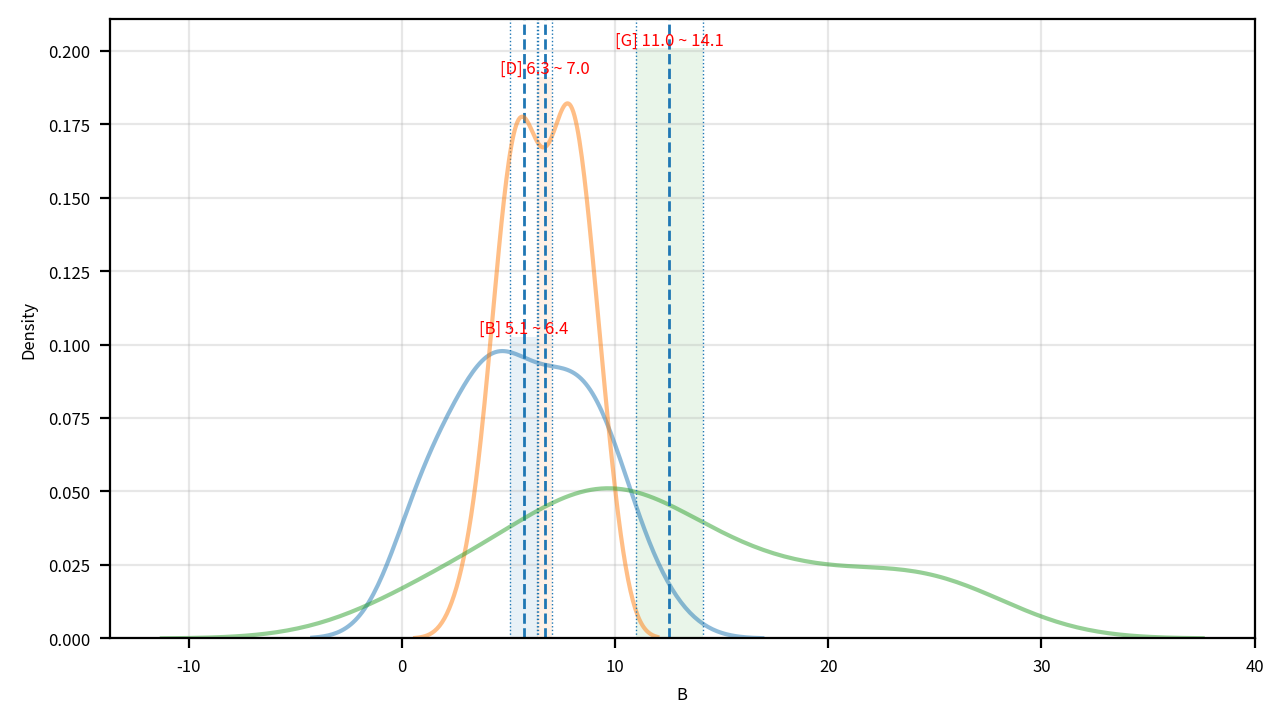

In [243]:
# 📝 [1] 데이터 분포
data = df_reading[['B','D','G']] # 확인할 데이터
# ---------------------------------
# 데이터 분포 / 신뢰구간 시각화
# ---------------------------------
# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)
    # 신뢰구간
    max = data[c].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(data[c]) - 1 # 자유도
    sp_mean = data[c].mean() # 표본평균
    sp_std = data[c].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)
    # 평균 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax.text(x=(cmax-cmin)/2+cmin,
            y=ymax,
            s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
            horizontalalignment="center",
            verticalalignment="bottom",
            fontdict={"size": 6, "color": "red"})
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시/숨김
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📝 2. 데이터 분포 확인-T

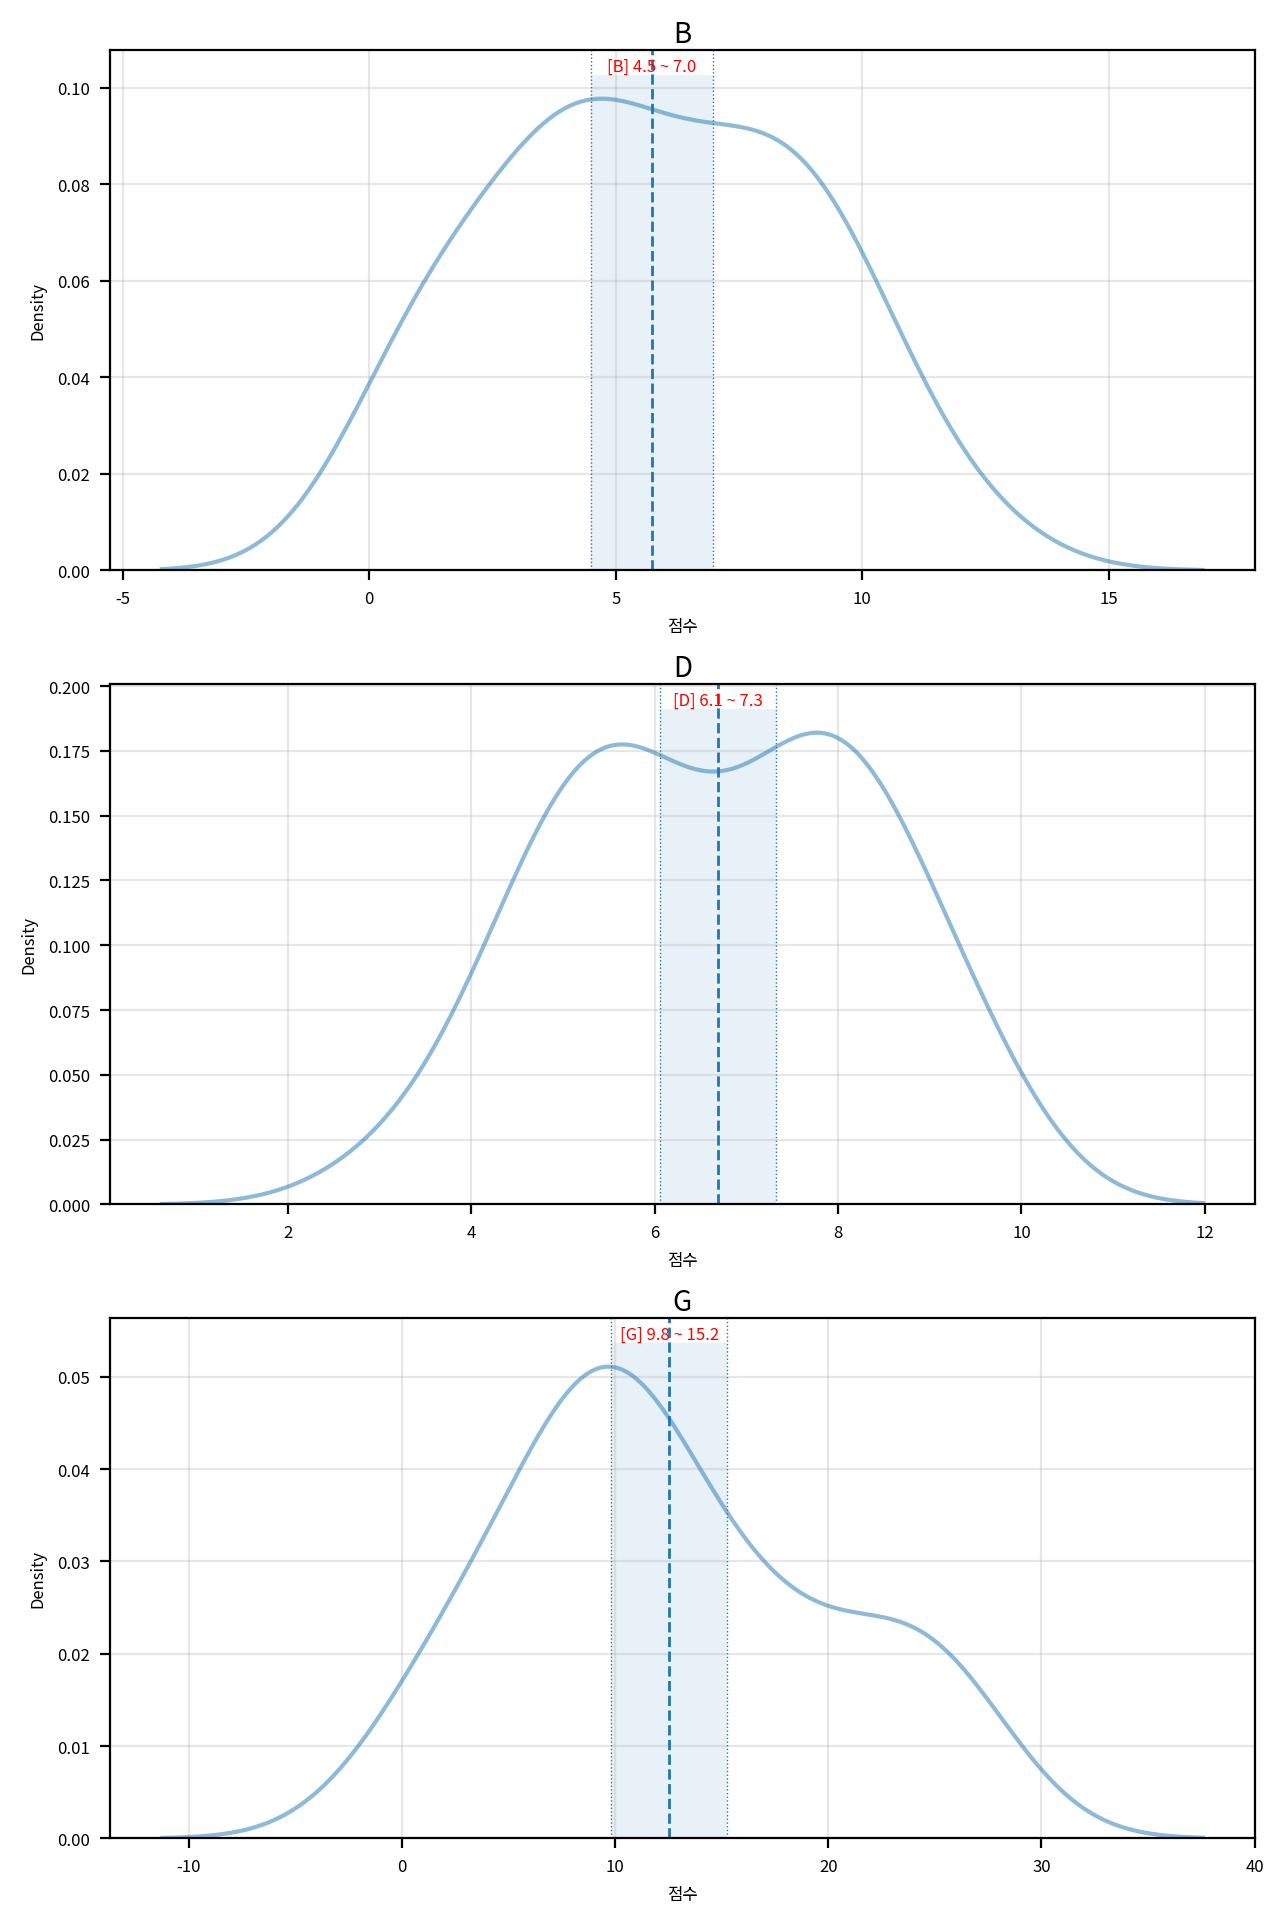

In [247]:
field = '점수' # 확인할 데이터 필드
hue_field = '독서방법' # 집단을 구분하는 필드 (hue)
df = reading[[field, hue_field]] # 필요한 데이터 추출
hue_values = df[hue_field].unique() # 집단별 종류 구하기
hue_count = len(hue_values) # 집단의 종류 수
# 1) 그래프 초기화
rows = len(hue_values) # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for i, v in enumerate(hue_values):
    temp = df[df[hue_field] == v]
    # KDE Plot 그리기
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)
    # 신뢰구간
    max = temp[field].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(temp[field]) - 1 # 자유도
    sp_mean = temp[field].mean() # 표본평균
    sp_std = temp[field].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp[field])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
# 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (v, cmin, cmax),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📝 3. 정규성, 등분산성 검정-T

In [250]:
field = '점수' # 확인할 데이터 필드
hue_field = '독서방법' # 집단을 구분하는 필드 (hue)
df = reading.filter([field, hue_field]) # 필요한 데이터 추출
df['idx'] = df.groupby(hue_field).cumcount()
data = pivot_table(df, index='idx', columns=hue_field, values=field)
data.head()

독서방법,B,D,G
idx,,,
0,7.7,9.4,10.6
1,1.5,9.4,9.2
2,4.3,4.4,8.9
3,5.4,3.2,15.7
4,4.3,5.7,0.0


2) 정규성, 등분산성 확인

In [252]:
equal_var_fields = []
normal_dist = True
report = []
values = []
for c in data.columns:
    # 집단간 샘플수가 다를 수 있으므로 결측치를 제거하고 추출
    target = data[c].dropna()
    # 등분산성 검정을 위해 리스트에 모아둔다.
    values.append(target)
    # 정규성 검정
    s, p = normaltest(target)

    normalize = p > 0.05
    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })
    normal_dist = normal_dist and normalize
# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett" # 정규성을 충족할 경우의 정방법
        s, p = bartlett(*values) # 모든 컬럼의 데이터를 한번에 전달
    else:
        n = "Levene" # 정규성을 충족하지 않을 경우의 검정방법
        s, p = levene(*values, center='median') # 모든 컬럼의 데이터를 한번에 전달
    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })
# 등분산성을 충족하는지 확인
    equal_var = p > 0.05
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
B,2.210100,3.311943e-01,True
D,2.396634,3.017015e-01,True
G,2.216900,3.300701e-01,True
Bartlett,58.099241,2.420528e-13,False


📝 4. 집단간 평균 비교-T

In [255]:
field = '점수'
hue_field = '독서방법'
anova_df = reading[[field, hue_field]]
if equal_var:
    pg_anova = anova(data=anova_df, dv=field, between=hue_field)
else:
    pg_anova = welch_anova(data=anova_df, dv=field,
        between=hue_field)
display(pg_anova)
f_val = pg_anova['F'].iloc[0]
p_val = pg_anova['p-unc'].iloc[0]
display("statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(f_val, p_val, "대립" if p_val <= 0.05 else "귀무"))
if equal_var:
    print("=== Tukey HSD ===")
    hoc_df = pairwise_tukey(data=anova_df, dv=field,
        between=hue_field)
else:
    print("=== Games-Howell ===")
    hoc_df = pairwise_gameshowell(anova_df, dv=field,
        between=hue_field)
display(hoc_df)

,Source,ddof1,ddof2,F,p-unc,np2
0,독서방법,2,48.204128,10.787455,0.000134,0.283461


'statistic: 10.787, p-value: 0.000, 대립가설 채택'

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,B,D,5.732143,6.693333,-0.961190,0.676594,-1.420631,40.563109,0.339976,-0.375556
1,B,G,5.732143,12.531250,-6.799107,1.457054,-4.666340,42.964012,0.000088,-1.136960
2,D,G,6.693333,12.531250,-5.837917,1.362766,-4.283874,34.360873,0.000403,-1.043650


📝 인사이트-T

p < 0.001이므로 귀무가설(세 집단의 평균이 동일하다)을 기각하고<br>
대립가설(적어도 한 집단은 평균이 다르다)을 채택한다.<br>
효과크기 ηp² = 0.283 → 중간에서 큰 효과크기, 즉 읽기방법이 학습 성과에 상당한 영<br>
향력을 가짐.<br>
2. 집단별 평균(독서평가 점수)<br>
집단 G는 B와 D 모두보다 매우 높은 독서평가 점수를 기록함.<br>
집단 G가 가장 높은 점수, B가 가장 낮은 점수를 보임<br>
3. 사후검정(Games–Howell) 결과 요약<br>
4. 결론 요약<br>
ANOVA에서 읽기방법에 따른 평균 점수 차이가 통계적으로 유의하게 나타남.<br>
집단 B와 D는 유의미한 차이가 없음.<br>
Games–Howell 사후검정에서 두 유의한 비교(B–G, D–G)는 모두 p < 0.001 수준으<br>
로 강한 차이를 보임.<br>
효과크기(hedges g)가 모두 |g| > 1 수준으로, 읽기방법 G의 효과가 매우 큼을 의미함.<br>
전체적으로 읽기방법 G가 학습 효율이 압도적으로 뛰어나다고 해석할 수 있음.<br>
읽기방법 10.787 0.000134<br>
세 읽기방법 간 평균 점수 차이<br>
가 통계적으로 유의함<br>
읽기방법 G는 유아들의 독서평가 점수를 크게 향상시키는 데 가장 효과적인 방식이며,<br>
B와<br>
D는 서로 통계적으로 구분되지 않는다.<br>
G는 다른 두 방법보다 통계적으로도, 효과크기 측면에서도 월등히 높은 성과를 보인다.

In [198]:
import pingouin as pg

anova_result = pg.anova(data=reading, dv='점수', between='독서방법')
print(anova_result)

if p_value <= 0.05:
    print("결론: 그룹 간 평균 차이가 **유의미함**\n")
else:
    print("결론: 그룹 간 평균 차이가 **유의미하지 않음**\n")
# p-value만 출력
p_value = anova_result['p-unc'][0]


  Source  ddof1  ddof2          F         p-unc       np2
0   독서방법      2     87  17.208501  5.045789e-07  0.283461
결론: 그룹 간 평균 차이가 **유의미함**



사후검정

In [206]:
import pingouin as pg
import pandas as pd
from scipy.stats import levene, shapiro

# =====================================================
# 1. 그룹 분리
# =====================================================
groups = reading['독서방법'].unique()

group_data = {g: reading[reading['독서방법'] == g]['점수'] for g in groups}

# =====================================================
# 2. 정규성 검정 (Shapiro-Wilk)
# =====================================================
print("=== 정규성 검정 (Shapiro-Wilk) ===")
normality_results = {}
for g in groups:
    stat, p = shapiro(group_data[g])
    normality_results[g] = p
    print(f"{g} 그룹: p-value={p:.4f} → {'정규성 만족' if p>0.05 else '정규성 위배'}")

print()

# =====================================================
# 3. 등분산성 검정 (Levene test)
# =====================================================
print("=== 등분산성 검정 (Levene) ===")
stat, p_levene = levene(*group_data.values())
print(f"Levene p-value={p_levene:.4f} → {'등분산 만족' if p_levene>0.05 else '등분산 위배'}")
print()

# =====================================================
# 4. ANOVA 실행 (조건에 따라 자동 선택)
# =====================================================
print("=== ANOVA 결과 ===")
if p_levene > 0.05:
    print("등분산 만족 → 일반 ANOVA 적용")
    anova_result = pg.anova(data=reading, dv='점수', between='독서방법')
else:
    print("등분산 위배 → Welch ANOVA 적용")
    anova_result = pg.welch_anova(data=reading, dv='점수', between='독서방법')

print(anova_result)
p_anova = anova_result['p-unc'][0]
print(f"\nANOVA p-value = {p_anova:.6f}")

if p_anova <= 0.05:
    print("결론: 그룹 간 평균 차이가 **유의미함**\n")
else:
    print("결론: 그룹 간 평균 차이가 **유의미하지 않음**\n")

# =====================================================
# 5. 사후검정 Post-hoc test
# =====================================================
print("=== 사후검정 (Post-hoc test) ===")
if p_levene > 0.05:
    print("등분산 만족 → Tukey HSD 사용\n")
    posthoc = pg.pairwise_tukey(data=reading, dv='점수', between='독서방법')
else:
    print("등분산 위배 → Games-Howell 사용\n")
    posthoc = pg.pairwise_gameshowell(data=reading, dv='점수', between='독서방법')

print(posthoc)

# =====================================================
# 6. 사후검정 해석 자동 생성
# =====================================================
print("\n=== 사후검정 자동 해석 ===")

for i in range(len(posthoc)):
    row = posthoc.iloc[i]
    g1, g2 = row['A'], row['B']
    pval = row['pval']
    mean_diff = row['diff']

    if pval <= 0.05:
        print(f"{g1} 그룹과 {g2} 그룹은 **유의미한 차이 있음(적어도 한 집단은 차이가 있음)** (p={pval:.4f}, 평균차={mean_diff:.3f})")
    else:
        print(f"{g1} 그룹과 {g2} 그룹은 유의미한 차이 없음 (p={pval:.4f})")


print(f"전체적으로 읽기방법 G가 학습 효율이 압도적으로 뛰어나다고 해석할 수 있음.")

=== 정규성 검정 (Shapiro-Wilk) ===
B 그룹: p-value=0.4320 → 정규성 만족
D 그룹: p-value=0.3428 → 정규성 만족
G 그룹: p-value=0.1134 → 정규성 만족

=== 등분산성 검정 (Levene) ===
Levene p-value=0.0000 → 등분산 위배

=== ANOVA 결과 ===
등분산 위배 → Welch ANOVA 적용
  Source  ddof1      ddof2          F     p-unc       np2
0   독서방법      2  48.204128  10.787455  0.000134  0.283461

ANOVA p-value = 0.000134
결론: 그룹 간 평균 차이가 **유의미함**

=== 사후검정 (Post-hoc test) ===
등분산 위배 → Games-Howell 사용

   A  B   mean(A)    mean(B)      diff        se         T         df  \
0  B  D  5.732143   6.693333 -0.961190  0.676594 -1.420631  40.563109   
1  B  G  5.732143  12.531250 -6.799107  1.457054 -4.666340  42.964012   
2  D  G  6.693333  12.531250 -5.837917  1.362766 -4.283874  34.360873   

       pval    hedges  
0  0.339976 -0.375556  
1  0.000088 -1.136960  
2  0.000403 -1.043650  

=== 사후검정 자동 해석 ===
B 그룹과 D 그룹은 유의미한 차이 없음 (p=0.3400)
B 그룹과 G 그룹은 **유의미한 차이 있음(적어도 한 집단은 차이가 있음)** (p=0.0001, 평균차=-6.799)
D 그룹과 G 그룹은 **유의미한 차이 있음(적어도 한 집단은 차이가 있음)** (p

D그룹과 G그룹을 비교했을 때,p-value의 값이 0.0004로(p-value < 0.05) 나타나는 것으로 보아 통계적으로 유의미한 차이가 있다고 볼 수 있다.

📝 문제 3

commercial 데이터셋 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료이<br>
다.<br>
서울시에서 정의하는 상권의 종류는 발달상권, 골목상권, 관광특구, 전통시장이 있다.<br>
상권 종류별 2023년 한 해 동안의 평균 매출액은 어떤 차이가 보이는지 분석하라.<br>
주어진 데이터는 서울시에서 제공하는 집계가 완료된 데이터이므로 모든 결측치는 없는 상태이<br>
며 이상치도 실제 매출액 데이터이므로 별도의 정제 과정 없이 진행하는 것으로 한다.<br>

In [ ]:
commercial = load_data('commercial')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {commercial.shape}")
print(f"열 개수: {commercial.shape[1]}")
print(f"행 개수: {commercial.shape[0]}")
print("\n===== 타입확인 =====")
print(commercial.info())
commercial

[data] https://data.hossam.kr/data/lab10_/commercial.xlsx
[desc] 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (6222, 6)
열 개수: 6
행 개수: 6222

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6222 entries, 0 to 6221
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   quarter          6222 non-null   int64 
 1   code             6222 non-null   int64 
 2   type             6222 non-null   object
 3   name             6222 non-null   object
 4   sales_amount     6222 non-null   int64 
 5   number_of_sales  6222 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 291.8+ KB
None


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166
...,...,...,...,...,...,...
6217,4,3130323,전통시장,둔촌역전통시장,13523478306,535132
6218,4,3130324,전통시장,길동복조리시장,6236556030,330148
6219,4,3130325,전통시장,명일전통시장,3973269286,186049
6220,4,3130326,전통시장,고덕 골목형상점가,15013907999,755565


골목상권,관광특구,발달상권의 매출건수

In [ ]:
df_commercial1 = commercial.pivot(columns='type', values='number_of_sales')
print(df_commercial1)

type  골목상권        관광특구  발달상권      전통시장
0      NaN   2496865.0   NaN       NaN
1      NaN  10246122.0   NaN       NaN
2      NaN   2880324.0   NaN       NaN
3      NaN   4960006.0   NaN       NaN
4      NaN   5995166.0   NaN       NaN
...    ...         ...   ...       ...
6217   NaN         NaN   NaN  535132.0
6218   NaN         NaN   NaN  330148.0
6219   NaN         NaN   NaN  186049.0
6220   NaN         NaN   NaN  755565.0
6221   NaN         NaN   NaN   89630.0

[6222 rows x 4 columns]


In [ ]:
print("=====매출건수의 NaN 수=====")
n1 = df_commercial1['골목상권'].isna().sum()
n2 = df_commercial1['관광특구'].isna().sum()
n3 = df_commercial1['발달상권'].isna().sum()

print(f"골목상권의 NaN값은 총{n1}개입니다")
print(f"골목상권의 NaN값은 총{n2}개입니다")
print(f"골목상권의 NaN값은 총{n3}개입니다")

=====매출건수의 NaN 수=====
골목상권의 NaN값은 총2129개입니다
골목상권의 NaN값은 총6198개입니다
골목상권의 NaN값은 총5226개입니다


골목상권,관광특구,발달상권의 매출액

In [ ]:
df_commercial2 = commercial.pivot(columns='type', values='sales_amount')
print(df_commercial2)

type  골목상권          관광특구  발달상권          전통시장
0      NaN  7.252364e+10   NaN           NaN
1      NaN  2.833323e+11   NaN           NaN
2      NaN  8.169673e+10   NaN           NaN
3      NaN  2.120627e+11   NaN           NaN
4      NaN  2.313384e+11   NaN           NaN
...    ...           ...   ...           ...
6217   NaN           NaN   NaN  1.352348e+10
6218   NaN           NaN   NaN  6.236556e+09
6219   NaN           NaN   NaN  3.973269e+09
6220   NaN           NaN   NaN  1.501391e+10
6221   NaN           NaN   NaN  1.939173e+10

[6222 rows x 4 columns]


In [ ]:
print("=====매출액의 NaN 수=====")
n1_1 = df_commercial2['골목상권'].isna().sum()
n2_2 = df_commercial2['관광특구'].isna().sum()
n3_3 = df_commercial2['발달상권'].isna().sum()

print(f"골목상권의 NaN값은 총{n1_1}개입니다")
print(f"골목상권의 NaN값은 총{n2_2}개입니다")
print(f"골목상권의 NaN값은 총{n3_3}개입니다")

=====매출액의 NaN 수=====
골목상권의 NaN값은 총2129개입니다
골목상권의 NaN값은 총6198개입니다
골목상권의 NaN값은 총5226개입니다


골목상권, 관광특구, 발달상권의 매출건수와 매출액

In [ ]:
df_commercial1 = df_commercial1.add_suffix('_건수')
df_commercial2 = df_commercial2.add_suffix('_매출액')
df_merged = pd.concat([df_commercial1, df_commercial2], axis=1)
print(df_merged)


type  골목상권_건수_건수_건수  관광특구_건수_건수_건수  발달상권_건수_건수_건수  전통시장_건수_건수_건수  \
0               NaN      2496865.0            NaN            NaN   
1               NaN     10246122.0            NaN            NaN   
2               NaN      2880324.0            NaN            NaN   
3               NaN      4960006.0            NaN            NaN   
4               NaN      5995166.0            NaN            NaN   
...             ...            ...            ...            ...   
6217            NaN            NaN            NaN       535132.0   
6218            NaN            NaN            NaN       330148.0   
6219            NaN            NaN            NaN       186049.0   
6220            NaN            NaN            NaN       755565.0   
6221            NaN            NaN            NaN        89630.0   

type  골목상권_매출액_매출액_매출액  관광특구_매출액_매출액_매출액  발달상권_매출액_매출액_매출액  전통시장_매출액_매출액_매출액  
0                  NaN      7.252364e+10               NaN               NaN  
1                  NaN   

In [ ]:
import pingouin as pg

anova_result = pg.anova(data=commercial, dv='sales_amount', between='type')
print(anova_result)

# p-value만 출력
p_value = anova_result['p-unc'][0]
print("p-value:", p_value)
print(f"p-value의 값이{"p-unc"}인 것으로 보아, 골목상권, 관광특구, 발달상권의 평균 매출액의 차이는 유의미 한 것으로 나타났습니다.")

  Source  ddof1  ddof2           F  p-unc       np2
0   type      3   6218  612.136531    0.0  0.228001
p-value: 0.0
p-value의 값이p-unc인 것으로 보아, 골목상권, 관광특구, 발달상권의 평균 매출액의 차이는 유의미 한 것으로 나타났습니다.


각 그룹별 정규성 검사:

In [ ]:
from scipy.stats import shapiro

for g in commercial['type'].unique():
    data_g = commercial[commercial['type'] == g]['sales_amount']
    stat, p = shapiro(data_g)
    print(f"{g} 그룹 정규성 p-value = {p}")

print(f"4개의 독립된 그룹은 p-value > 0.05이므로, 정규성을 만족하는것으로 나타났습니다.")


관광특구 그룹 정규성 p-value = 0.10607694362220016
골목상권 그룹 정규성 p-value = 1.960546680714281e-66
발달상권 그룹 정규성 p-value = 1.0869719605019333e-48
전통시장 그룹 정규성 p-value = 1.1912877885456535e-48
4개의 독립된 그룹은 p-value > 0.05이므로, 정규성을 만족하는것으로 나타났습니다.


등분산성 검사 (Levene)

In [ ]:
from scipy.stats import levene

groups = [commercial[commercial['type'] == g]['sales_amount']
          for g in commercial['type'].unique()]

stat, p_levene = levene(*groups)
print("Levene p-value =", p_levene)
print(f"등분산성을 위배하는 것으로 보입니다.")


Levene p-value = 5.3007176621731654e-164
등분산성을 위배하는 것으로 보입니다.


등분산 만족 → Tukey HSD

In [ ]:
pg.pairwise_tukey(data=commercial, dv='sales_amount', between='type')

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,골목상권,관광특구,3.659509e+09,2.281432e+11,-2.244837e+11,8.805706e+09,-25.492978,1.766587e-12,-23.206979
1,골목상권,발달상권,3.659509e+09,5.706310e+10,-5.340359e+10,1.519728e+09,-35.140221,1.766587e-12,-1.160433
2,골목상권,전통시장,3.659509e+09,1.058420e+10,-6.924689e+09,1.456125e+09,-4.755558,1.203305e-05,-0.679464
3,관광특구,발달상권,2.281432e+11,5.706310e+10,1.710801e+11,8.885156e+09,19.254597,1.766587e-12,1.647276
4,관광특구,전통시장,2.281432e+11,1.058420e+10,2.175590e+11,8.874498e+09,24.515075,1.766587e-12,8.536768
5,발달상권,전통시장,5.706310e+10,1.058420e+10,4.647890e+10,1.877720e+09,24.752836,1.766587e-12,0.638976


In [256]:
import pingouin as pg
import pandas as pd
from scipy.stats import levene, shapiro

# =====================================================
# 1. 그룹 분리
# =====================================================
groups = commercial['type'].unique()

group_data = {g: commercial[commercial['type'] == g]['sales_amount'] for g in groups}

# =====================================================
# 2. 정규성 검정 (Shapiro-Wilk)
# =====================================================
print("=== 정규성 검정 (Shapiro-Wilk) ===")
normality_results = {}
for g in groups:
    stat, p = shapiro(group_data[g])
    normality_results[g] = p
    print(f"{g} 그룹: p-value={p:.4f} → {'정규성 만족' if p>0.05 else '정규성 위배'}")

print()

# =====================================================
# 3. 등분산성 검정 (Levene test)
# =====================================================
print("=== 등분산성 검정 (Levene) ===")
stat, p_levene = levene(*group_data.values())
print(f"Levene p-value={p_levene:.4f} → {'등분산 만족' if p_levene>0.05 else '등분산 위배'}")
print()

# =====================================================
# 4. ANOVA 실행 (조건에 따라 자동 선택)
# =====================================================
print("=== ANOVA 결과 ===")
if p_levene > 0.05:
    print("등분산 만족 → 일반 ANOVA 적용")
    anova_result = pg.anova(data=origin, dv='weight', between='group')
else:
    print("등분산 위배 → Welch ANOVA 적용")
    anova_result = pg.welch_anova(data=commercial, dv='sales_amount', between='type')

print(anova_result)
p_anova = anova_result['p-unc'][0]
print(f"\nANOVA p-value = {p_anova:.6f}")

if p_anova <= 0.05:
    print("결론: 그룹 간 평균 차이가 **유의미함**\n")
else:
    print("결론: 그룹 간 평균 차이가 **유의미하지 않음**\n")

# =====================================================
# 5. 사후검정 Post-hoc test
# =====================================================
print("=== 사후검정 (Post-hoc test) ===")
if p_levene > 0.05:
    print("등분산 만족 → Tukey HSD 사용\n")
    posthoc = pg.pairwise_tukey(data=origin, dv='weight', between='group')
else:
    print("등분산 위배 → Games-Howell 사용\n")
    posthoc = pg.pairwise_gameshowell(data=commercial, dv='sales_amount', between='type')

print(posthoc)

# =====================================================
# 6. 사후검정 해석 자동 생성
# =====================================================
print("\n=== 사후검정 자동 해석 ===")

for i in range(len(posthoc)):
    row = posthoc.iloc[i]
    g1, g2 = row['A'], row['B']
    pval = row['pval']
    mean_diff = row['diff']

    if pval <= 0.05:
        print(f"{g1} 그룹과 {g2} 그룹은 **유의미한 차이 있음** (p={pval:.4f}, 평균차={mean_diff:.3f})")
    else:
        print(f"{g1} 그룹과 {g2} 그룹은 유의미한 차이 없음 (p={pval:.4f})")


=== 정규성 검정 (Shapiro-Wilk) ===
관광특구 그룹: p-value=0.1061 → 정규성 만족
골목상권 그룹: p-value=0.0000 → 정규성 위배
발달상권 그룹: p-value=0.0000 → 정규성 위배
전통시장 그룹: p-value=0.0000 → 정규성 위배

=== 등분산성 검정 (Levene) ===
Levene p-value=0.0000 → 등분산 위배

=== ANOVA 결과 ===
등분산 위배 → Welch ANOVA 적용
  Source  ddof1       ddof2           F         p-unc       np2
0   type      3  110.238825  161.432719  3.495920e-40  0.228001

ANOVA p-value = 0.000000
결론: 그룹 간 평균 차이가 **유의미함**

=== 사후검정 (Post-hoc test) ===
등분산 위배 → Games-Howell 사용

      A     B       mean(A)       mean(B)          diff            se  \
0  골목상권  관광특구  3.659509e+09  2.281432e+11 -2.244837e+11  2.289216e+10   
1  골목상권  발달상권  3.659509e+09  5.706310e+10 -5.340359e+10  3.282878e+09   
2  골목상권  전통시장  3.659509e+09  1.058420e+10 -6.924689e+09  6.060559e+08   
3  관광특구  발달상권  2.281432e+11  5.706310e+10  1.710801e+11  2.312611e+10   
4  관광특구  전통시장  2.281432e+11  1.058420e+10  2.175590e+11  2.289993e+10   
5  발달상권  전통시장  5.706310e+10  1.058420e+10  4.647890e+10  3.336641e

따라서, 골목상권,관광특구,발달상권,전통시장 이렇게 네 가지의 상권의 평균 매출액에는 유의미한 차이가 있는 것으로 나타났다.

📝 2. 데이터 분포 확인-T

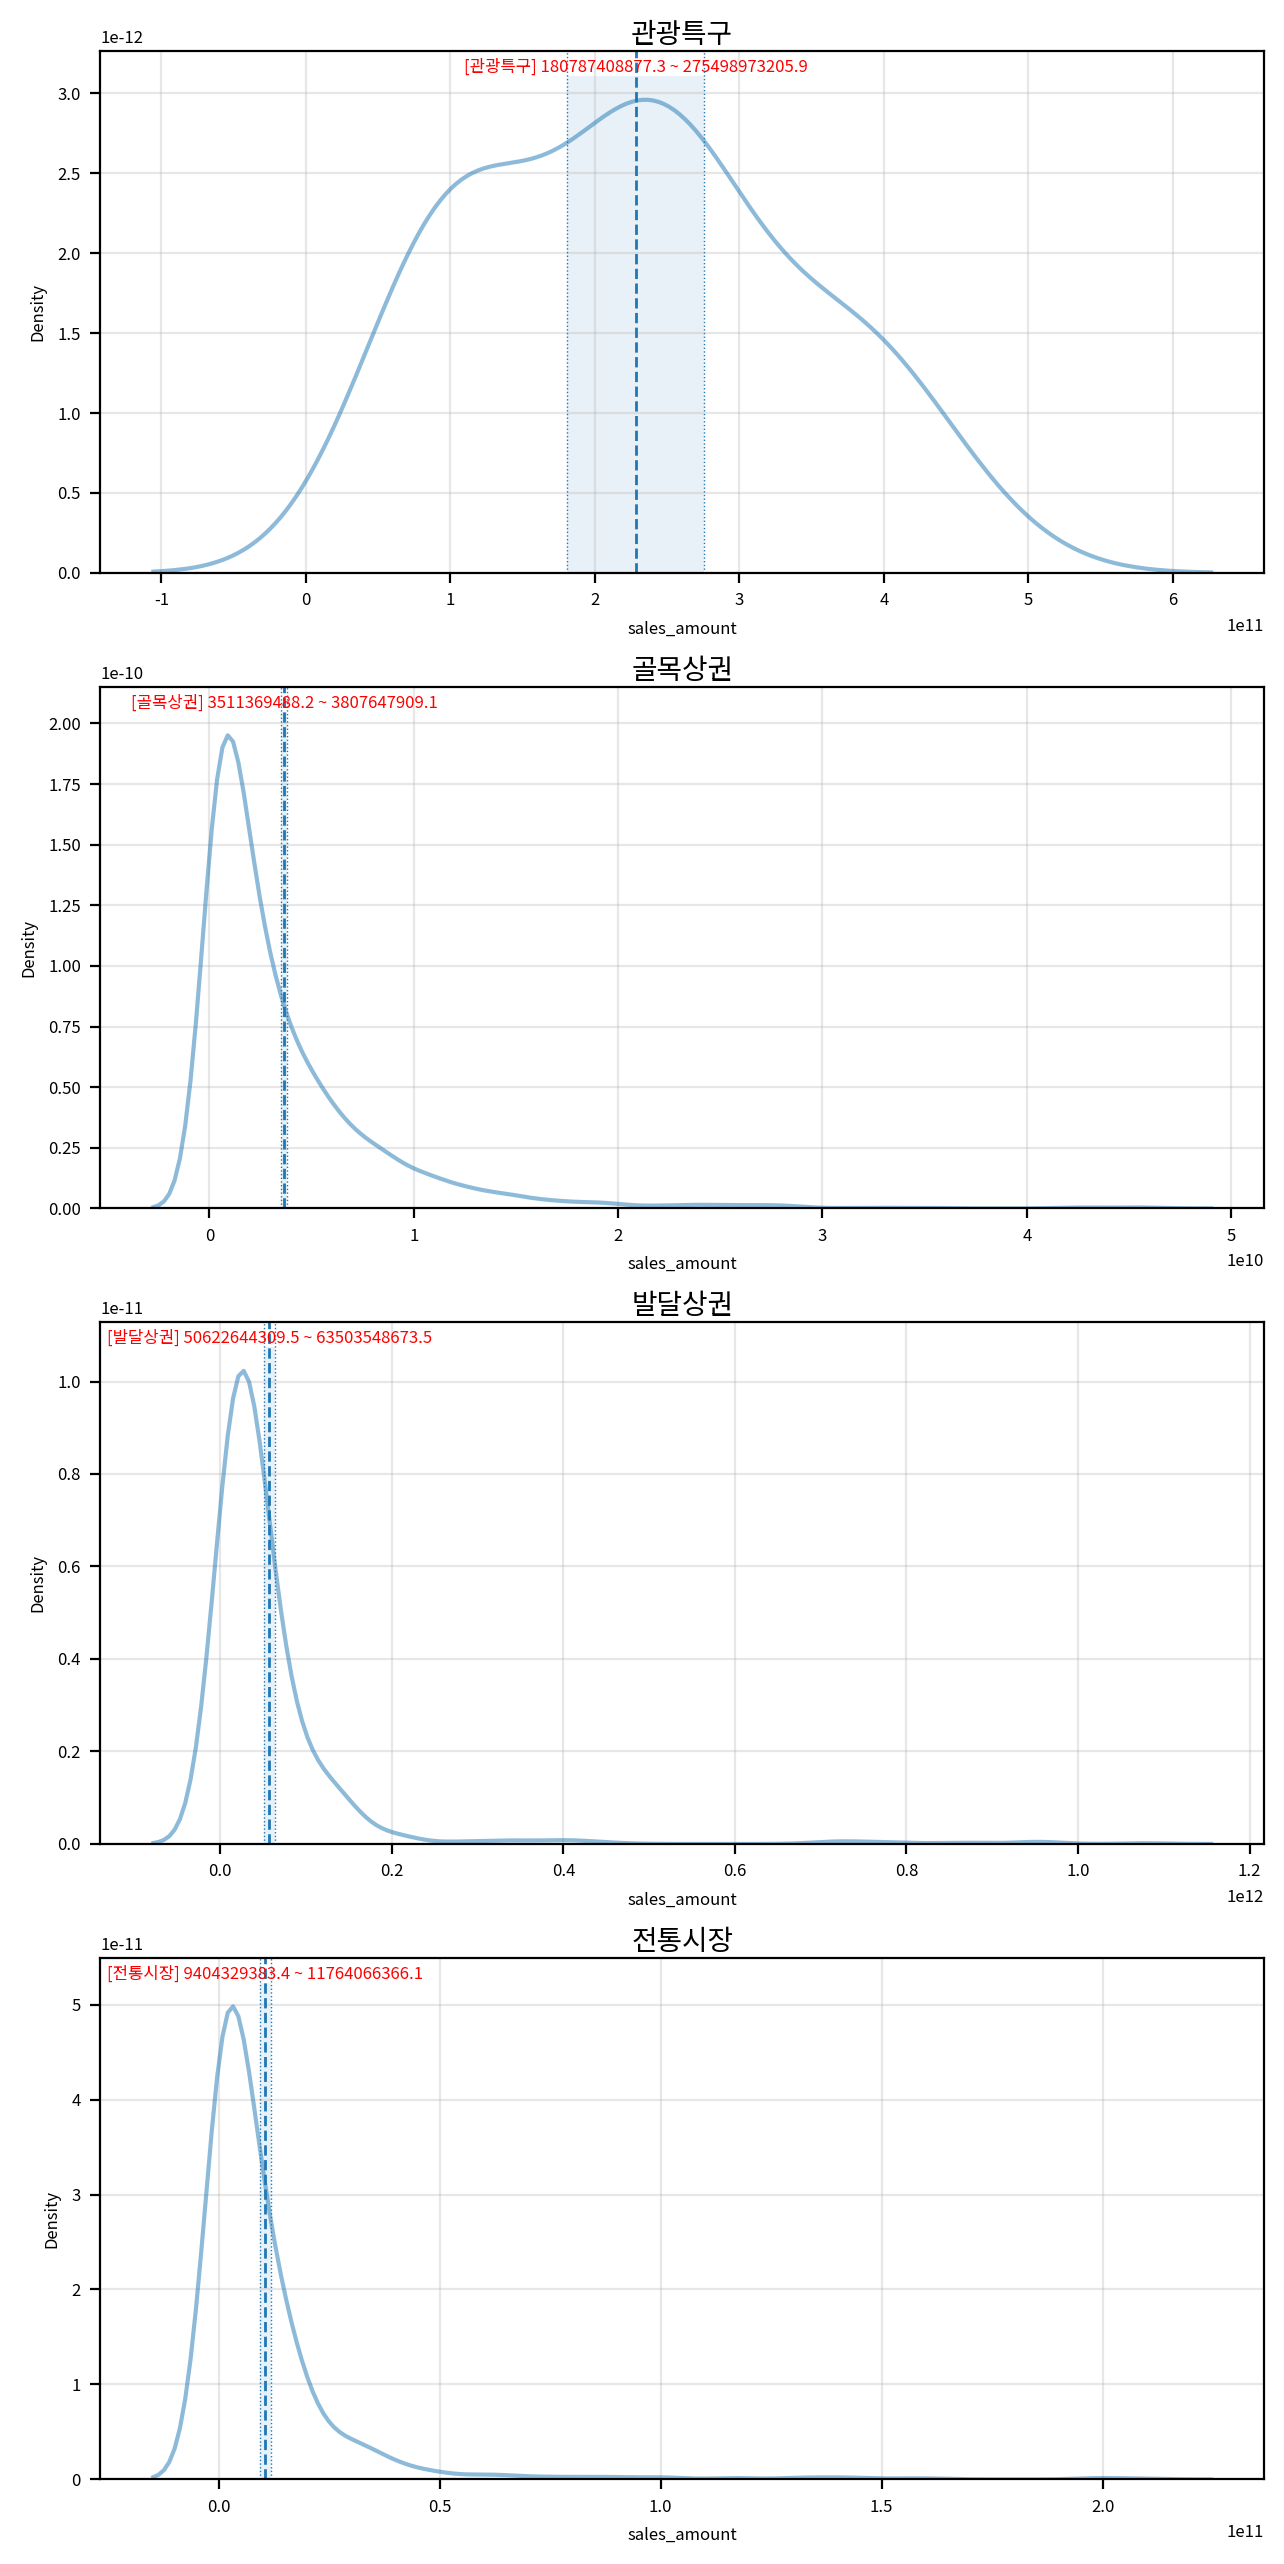

In [259]:
field = 'sales_amount' # 확인할 데이터 필드
hue_field = 'type' # 집단을 구분하는 필드 (hue)
df = commercial[[field, hue_field]] # 필요한 데이터 추출
hue_values = df[hue_field].unique() # 집단별 종류 구하기
hue_count = len(hue_values) # 집단의 종류 수
# 1) 그래프 초기화
rows = len(hue_values) # 그래프 행 수
cols = 1 # 그래프 열 수
width_px = 1280 # 그래프 가로 크기
height_px = 640 * rows # 그래프 세로 크기
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
for i, v in enumerate(hue_values):
    temp = df[df[hue_field] == v]
    # KDE Plot 그리기
    sb.kdeplot(data=temp, x=field, fill=False, alpha=0.5, ax=ax[i])
    ax[i].grid(True, alpha=0.3)
    ax[i].set_title(v, fontsize=10, pad=3)
    # 신뢰구간
    max = temp[field].max() # 최대값
    clevel = 0.95 # 신뢰수준
    dof = len(temp[field]) - 1 # 자유도
    sp_mean = temp[field].mean() # 표본평균
    sp_std = temp[field].std(ddof=1) # 표본표준편차
    sp_std_error = sp_std / sqrt(len(temp[field])) # 표본표준오차
    cmin, cmax = t.interval(clevel, dof, loc=sp_mean,
        scale=sp_std_error)
    ax[i].axvline(cmin, linestyle=':', linewidth=0.5)
    ax[i].axvline(cmax, linestyle=':', linewidth=0.5)
# 평균 표시
    ymin, ymax = ax[i].get_ylim()
    ax[i].fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax[i].axvline(sp_mean, linestyle='--', linewidth=1)
    # 텍스트 그리기
    ax[i].text(x=(cmax-cmin)/2+cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (v, cmin, cmax),
    horizontalalignment="center",
    verticalalignment="bottom",
    fontdict={"size": 6, "color": "red"})
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

📝 3. 정규성, 등분산성 검정-T

In [262]:
field = 'sales_amount'
hue_field = 'type'
df = commercial.filter([field,hue_field])
df['idx'] = df.groupby(hue_field).cumcount()
data = pivot_table(df, index='idx', columns=hue_field, values=field)
equal_var_fields = []
normal_dist = True
report = []
values = []
for c in data.columns:
    # 집단간 샘플수가 다를 수 있으므로 결측치를 제거하고 추출
    target = data[c].dropna()
    # 등분산성 검정을 위해 리스트에 모아둔다.
    values.append(target)
    # 정규성 검정
    s, p = normaltest(target)

    normalize = p > 0.05
    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })
    normal_dist = normal_dist and normalize
# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett" # 정규성을 충족할 경우의 정방법
        s, p = bartlett(*values) # 모든 컬럼의 데이터를 한번에 전달
    else:
        n = "Levene" # 정규성을 충족하지 않을 경우의 검정방법
        s, p = levene(*values, center='median') # 모든 컬럼의 데이터를 한번에 전달
    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })
# 등분산성을 충족하는지 확인
    equal_var = p > 0.05
report_df = DataFrame(report).set_index('field')
report_df

,statistic,p-value,result
field,,,
골목상권,2949.769498,0.000000e+00,False
관광특구,2.023450,3.635912e-01,True
발달상권,1174.363632,9.776365e-256,False
전통시장,1194.779826,3.604601e-260,False
Levene,268.725277,5.300718e-164,False


📝 4. 집단간 평균 비교-T

In [265]:
field = 'sales_amount'
hue_field = 'type'
anova_df = commercial[[field, hue_field]]
if equal_var:
    pg_anova = anova(data=anova_df, dv=field, between=hue_field)
else:
    pg_anova = welch_anova(data=anova_df, dv=field,
        between=hue_field)
display(pg_anova)
f_val = pg_anova['F'].iloc[0]
p_val = pg_anova['p-unc'].iloc[0]
display("statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(f_val, p_val, "대립" if p_val <= 0.05 else "귀무"))
if equal_var:
    print("=== Tukey HSD ===")
    hoc_df = pairwise_tukey(data=anova_df, dv=field,
        between=hue_field)
else:
    print("=== Games-Howell ===")
    hoc_df = pairwise_gameshowell(anova_df, dv=field,
        between=hue_field)
display(hoc_df)

,Source,ddof1,ddof2,F,p-unc,np2
0,type,3,110.238825,161.432719,3.495920e-40,0.228001


'statistic: 161.433, p-value: 0.000, 대립가설 채택'

=== Games-Howell ===


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,골목상권,관광특구,3.659509e+09,2.281432e+11,-2.244837e+11,2.289216e+10,-9.806138,23.000501,6.410146e-09,-23.206979
1,골목상권,발달상권,3.659509e+09,5.706310e+10,-5.340359e+10,3.282878e+09,-16.267309,996.054989,7.271961e-14,-1.160433
2,골목상권,전통시장,3.659509e+09,1.058420e+10,-6.924689e+09,6.060559e+08,-11.425826,1143.188337,0.000000e+00,-0.679464
3,관광특구,발달상권,2.281432e+11,5.706310e+10,1.710801e+11,2.312611e+10,7.397704,23.954998,7.128281e-07,1.647276
4,관광특구,전통시장,2.281432e+11,1.058420e+10,2.175590e+11,2.289993e+10,9.500421,23.031751,1.140238e-08,8.536768
5,발달상권,전통시장,5.706310e+10,1.058420e+10,4.647890e+10,3.336641e+09,13.929848,1061.849622,3.926859e-13,0.638976


📝 인사이트-T

1. 분산분석(ANOVA) 결과<br>
p-value가 사실상 0에 가까움 → 귀무가설 기각, 대립가설 채택<br>
효과크기 ηp² = 0.228 → 중간 이상~큰 효과, 상권 유형은 매출액에 매우 강한 영향 요<br>
인<br>
2. 상권 유형별 평균 매출액<br>
관광특구가 압도적으로 가장 매출이 높고, 골목상권이 가장 낮다.<br>

4. 객관적 사실 정리<br>
ANOVA 결과, 상권 유형에 따라 매출액의 평균이 통계적으로 매우 크게 차이남.<br>
관광특구의 평균 매출액은 모든 상권을 압도적으로 상회함.<br>
골목상권은 네 상권 중 가장 낮은 매출 규모를 보임.<br>
모든 비교쌍에서 통계적 유의성이 확인됨 →<br>
상권 유형 간 매출액은 서로 확실히 다름.<br>
특히 관광특구는 발달상권·전통시장·골목상권 모두와의 차이가 매우 크며,<br>
효과크기(hedges g)가 절대값 8~23 수준으로 극도로 큰 효과가 나타남.<br>
이는 관광특구의 매출 구조가 다른 상권과 전혀 다른 스케일로 운영되고 있음을 의미함.<br>
발달상권과 전통시장도 유의하게 다르며, 발달상권 > 전통시장 > 골목상권 순으로 매출<br>
규모가 커짐.<br>
5. 결론 요약<br>
2023년 서울시 상권 유형별 평균 매출액은 서로 유의하게 다른 패턴을 보이며,<br>
특히 관광특구는 다른 모든 상권 대비 압도적으로 높은 매출 규모를 가진다.<br>
전체 순위는 관광특구 > 발달상권 > 전통시장 > 골목상권이다.1